# 3. Lựa chọn đặc trưng

**Input:** `exps/feature0/x_train.csv, y_train.csv`  
**Output:** `exps/feature0/selected_features.json` — từ điển {tên_cách_chọn: [danh sách cột]}

BEGIN

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import sys; sys.path.insert(0, "../../extra")
from config import *
from common import *
from utils import *
display.clear_output()

In [3]:
MEMBER   = "baseline"      # tên/mã thành viên -> file log riêng
NOTEBOOK = "feature_selection"
FEATURE_SET = "feature0"
seed_everything()

In [4]:
from sklearn.linear_model import Lasso, Ridge
from sklearn.ensemble import GradientBoostingRegressor
x_train, y_train, x_test, test_id = load_feature_set(FEATURE_SET)

[load] feature0: x_train (1460, 289), x_test (1459, 289)


## 3.1. Lasso (L1) — giữ các cột có hệ số khác 0

Lasso giữ 218/289 cột


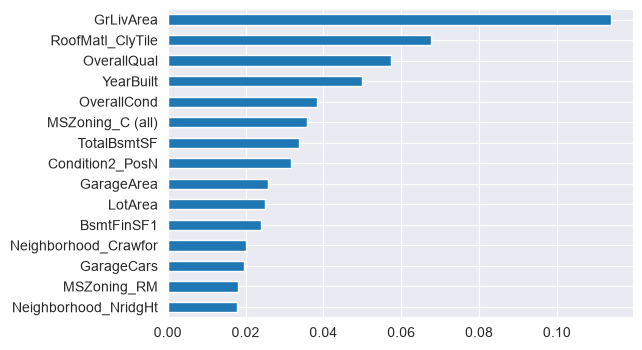

In [5]:
lasso = make_pipeline(Lasso(alpha=0.0005, max_iter=50000)).fit(x_train, y_train)
coef = pd.Series(lasso.named_steps['model'].coef_, index=x_train.columns)
sel_lasso = coef[coef != 0].index.tolist()
print(f'Lasso giữ {len(sel_lasso)}/{x_train.shape[1]} cột')
coef.abs().sort_values(ascending=False).head(15)[::-1].plot.barh(figsize=(6, 4)); plt.show()

## 3.2. Feature importance của Gradient Boosting — top K

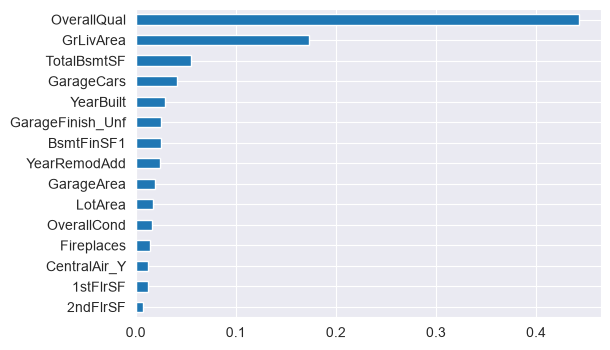

In [6]:
gbr = make_pipeline(GradientBoostingRegressor(n_estimators=300, random_state=SEED), scale=False).fit(x_train, y_train)
imp = pd.Series(gbr.named_steps['model'].feature_importances_, index=x_train.columns)
K = 50
sel_gbr = imp.sort_values(ascending=False).head(K).index.tolist()
imp.sort_values(ascending=False).head(15)[::-1].plot.barh(figsize=(6, 4)); plt.show()

## 3.3. So sánh nhanh bằng Ridge
⚠ Đặc trưng được chọn trên **toàn bộ** train rồi mới CV nên điểm hơi lạc quan; dùng để so sánh tương đối giữa các cách chọn.

In [7]:
selections = {'all': x_train.columns.tolist(), 'lasso': sel_lasso, f'gbr_top{K}': sel_gbr}
for name, cols in selections.items():
    scores, _ = evaluate(Ridge(alpha=10), x_train[cols], y_train)
    log_experiment(MEMBER, NOTEBOOK, FEATURE_SET, 'Ridge', scores, selection=name)

[log] Ridge        | feature0/all | CV RMSE = 0.14716 ± 0.04194
[log] Ridge        | feature0/lasso | CV RMSE = 0.14272 ± 0.04263
[log] Ridge        | feature0/gbr_top50 | CV RMSE = 0.14713 ± 0.04083


In [8]:
with open(f'{feature_dir(FEATURE_SET)}/selected_features.json', 'w') as f:
    json.dump(selections, f, indent=1)
list(selections)

['all', 'lasso', 'gbr_top50']

### Kết luận
- *(ghi nhận xét ở đây)*